# XG Boosting on Residuals of Prophet Models

In [347]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


from sklearn.model_selection import TimeSeriesSplit


import xgboost as xgb
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

from pandas.tseries.holiday import USFederalHolidayCalendar


from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')


import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

## Traing Prophet Model First

In [348]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

In [349]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2025-12-31")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

In [350]:
# For cross validation

cv_period = '14 days'

forecast_horizon = '14 days'

init_days = '1996 days'


### Tuning with Optuna

In [351]:
# import logging
# import optuna
# import numpy as np
# from prophet import Prophet
# from prophet.diagnostics import cross_validation, performance_metrics

# # Silence cmdstanpy logs
# logging.getLogger("cmdstanpy").setLevel(logging.WARNING)


# def objective(trial):

#     params = {
#         "changepoint_prior_scale": trial.suggest_float(
#             "changepoint_prior_scale", 0.001, 0.5, log=True
#         ),
#         "seasonality_prior_scale": trial.suggest_float(
#             "seasonality_prior_scale", 0.01, 15.0, log=True
#         ),
#     }

#     m = Prophet(**params)
#     m.fit(df)

#     df_cv = cross_validation(
#         m,
#         initial=init_days,
#         period=cv_period,
#         horizon=forecast_horizon,
#         disable_tqdm=True
#     )

#     # rolling_window=0 gives metrics per cutoff
#     df_p = performance_metrics(df_cv, rolling_window=0)

#     # Report intermediate values for pruning
#     for step, rmse in enumerate(df_p["rmse"].values):
#         trial.report(rmse, step)

#         if trial.should_prune():
#             raise optuna.TrialPruned()

#     return df_p["rmse"].mean()


# # Create study with pruner
# study = optuna.create_study(
#     direction="minimize",
#     pruner=optuna.pruners.MedianPruner(
#         n_startup_trials=5,
#         n_warmup_steps=2,
#         interval_steps=1,
#     ),
# )

# # Optimize
# study.optimize(objective, n_trials=30)

# print("Best Params:", study.best_params)
# print("Best RMSE:", study.best_value)

# best_params = study.best_params

In [352]:
# import logging
# logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# def objective(trial):

#     params = {
#         "changepoint_prior_scale": trial.suggest_float(
#             "changepoint_prior_scale", 0.001, 0.5, log=True
#         ),
#         "seasonality_prior_scale": trial.suggest_float(
#             "seasonality_prior_scale", 0.01, 15.0, log=True
#         ),
#     }

#     m = Prophet(**params)
#     m.fit(df)

#     df_cv = cross_validation(
#         m,
#         initial=init_days,
#         period=cv_period,
#         horizon=forecast_horizon,
#         disable_tqdm=True
#     )

#     df_p = performance_metrics(df_cv, rolling_window=1)
    
#     return df_p["rmse"].values[0]


# # Create study
# study = optuna.create_study(direction="minimize")

# # Optimize
# study.optimize(objective, n_trials=30)

# print("Best Params:", study.best_params)
# print("Best RMSE:", study.best_value)

# best_params = study.best_params

### Tuning with Grid

In [353]:
param_grid = {  
    'changepoint_prior_scale': [1],
    'seasonality_prior_scale': [0.01],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(df)  # Fit model with given params
    df_cv = cross_validation(m, initial=init_days, period=cv_period, horizon = forecast_horizon)
    df_p = performance_metrics(df_cv, rolling_window=14)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses

best_params = all_params[np.argmin(rmses)]

print(best_params)

15:32:52 - cmdstanpy - INFO - Chain [1] start processing
15:32:52 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/13 [00:00<?, ?it/s]

15:32:52 - cmdstanpy - INFO - Chain [1] start processing
15:32:53 - cmdstanpy - INFO - Chain [1] done processing
15:32:53 - cmdstanpy - INFO - Chain [1] start processing
15:32:53 - cmdstanpy - INFO - Chain [1] done processing
15:32:53 - cmdstanpy - INFO - Chain [1] start processing
15:32:53 - cmdstanpy - INFO - Chain [1] done processing
15:32:54 - cmdstanpy - INFO - Chain [1] start processing
15:32:54 - cmdstanpy - INFO - Chain [1] done processing
15:32:54 - cmdstanpy - INFO - Chain [1] start processing
15:32:54 - cmdstanpy - INFO - Chain [1] done processing
15:32:54 - cmdstanpy - INFO - Chain [1] start processing
15:32:55 - cmdstanpy - INFO - Chain [1] done processing
15:32:55 - cmdstanpy - INFO - Chain [1] start processing
15:32:55 - cmdstanpy - INFO - Chain [1] done processing
15:32:55 - cmdstanpy - INFO - Chain [1] start processing
15:32:56 - cmdstanpy - INFO - Chain [1] done processing
15:32:56 - cmdstanpy - INFO - Chain [1] start processing
15:32:56 - cmdstanpy - INFO - Chain [1]

{'changepoint_prior_scale': 1, 'seasonality_prior_scale': 0.01}


## Fit using the Tuned Parameters

In [354]:
best_params = {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10}

m = Prophet(holidays=holidays,
            changepoint_prior_scale = best_params['changepoint_prior_scale'],
            seasonality_prior_scale = best_params['seasonality_prior_scale'],
            weekly_seasonality = True,
            seasonality_mode = 'additive')
m.add_country_holidays(country_name='US')
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

# fig, ax = plt.subplots(figsize=(20, 6))  # make it wide
# m.plot(forecast, ax=ax)
# a = add_changepoints_to_plot(fig.gca(), m, forecast)

from prophet.plot import plot_plotly, plot_components_plotly

fig1 = plot_plotly(m, forecast)
fig1.show()

fig2 = plot_components_plotly(m, forecast)
fig2.show()

15:32:58 - cmdstanpy - INFO - Chain [1] start processing
15:32:58 - cmdstanpy - INFO - Chain [1] done processing


## Evaluate the Performance of Prophet against Actuals

In [355]:
# These were defined above and are here for a reminder.
# cv_period = '14 days'
# forecast_horizon = '14 days'
# init_days = '1996 days'

Uncomment the following codeblock to run the cross validation for the prophet model.

In [356]:
# df_cv = cross_validation(m, 
#                          initial=init_days, 
#                          period=cv_period, 
#                          horizon = forecast_horizon)

# df_p = performance_metrics(df_cv)
# df_p

## Set-up Dataframe of Residuals for XGBoost

In [357]:
dates = m.make_future_dataframe(periods=0)
dates

,ds
0,2020-01-01
1,2020-01-02
2,2020-01-03
3,2020-01-04
4,2020-01-05
...,...
2187,2025-12-27
2188,2025-12-28
2189,2025-12-29
2190,2025-12-30


Here is the prophet model on predictions from 2020-01-01 to 2025-12-31.

In [358]:
pp = m.predict(dates)[['ds','yhat']]

In [359]:
pp

,ds,yhat
0,2020-01-01,5.567836
1,2020-01-02,7.430404
2,2020-01-03,6.845241
3,2020-01-04,2.558096
4,2020-01-05,4.467146
...,...,...
2187,2025-12-27,3.626239
2188,2025-12-28,5.464936
2189,2025-12-29,11.686185
2190,2025-12-30,10.755648


In [360]:
residuals = df.copy()
residuals['y'] = df['y']-pp['yhat']
residuals

,ds,y
0,2020-01-01,-1.567836
1,2020-01-02,-0.430404
2,2020-01-03,9.154759
3,2020-01-04,7.441904
4,2020-01-05,0.532854
...,...,...
2187,2025-12-27,1.373761
2188,2025-12-28,-3.464936
2189,2025-12-29,-5.686185
2190,2025-12-30,-0.755648


In [361]:
residuals= residuals.set_index('ds')
residuals.index = pd.to_datetime(residuals.index)

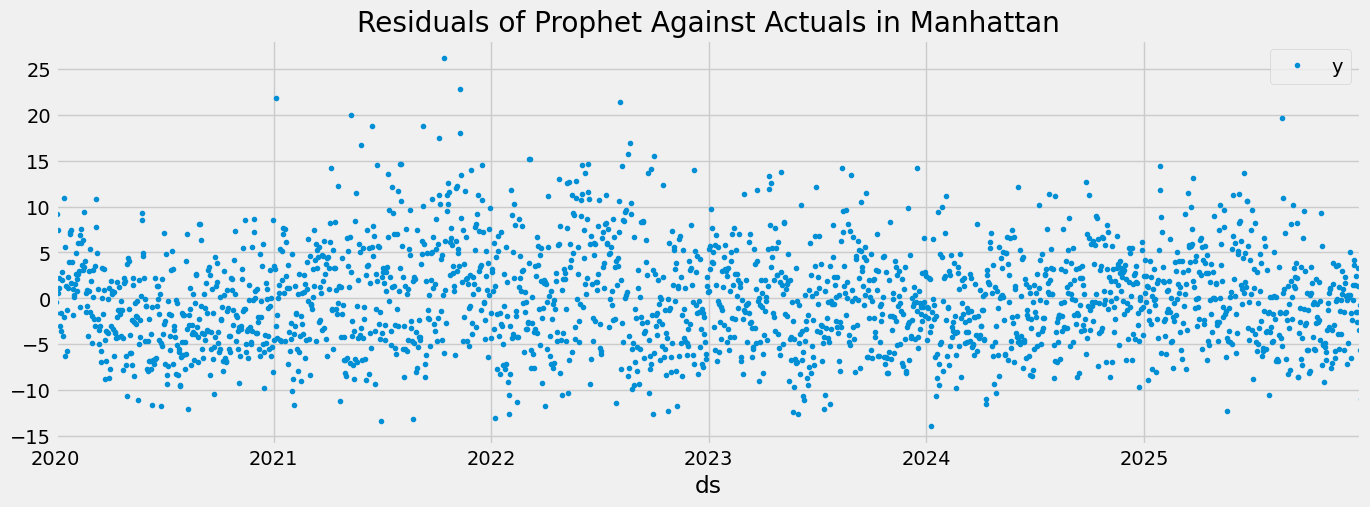

In [362]:
residuals.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='Residuals of Prophet Against Actuals in Manhattan')
plt.show()

## Add Features to apply XGBoost to Residuals

In [363]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

In [364]:
def add_cyclic(df):
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

In [365]:
def add_lags(df):
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    
    # Ensure sorted by date
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    df['ma7'] = df['y'].shift(1).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(1).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(1).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(1).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(1).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(1).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(1).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(1).rolling(window=365).mean()
    
    return df


In [366]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-12-31"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd

else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [367]:
# # Offline run

# nd = pd.read_csv("weatherdata.csv")
# nd = nd.set_index('date')
# wd = nd

In [368]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [369]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format → recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD → one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [370]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    # Convert start_date to datetime
    start_dt = pd.to_datetime(start_date)
    
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [371]:
# This must be run importing weather data

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    return df

In [372]:
residuals = create_features(residuals)
residuals = add_cyclic(residuals)
residuals = add_lags(residuals)
residuals = add_seasonal_lags(residuals)
residuals = add_moving_averages(residuals)
residuals = add_weather_data(residuals,wd)
residuals = add_more_weather_feature(residuals)
residuals = add_federal_holidays(residuals, custom_holidays = ['12-31'])
residuals = add_law_flag(residuals, law_name='Trash_Law', start_date = '2024-03-01')
residuals = add_law_flag(residuals, law_name = 'New_Trash_Law', start_date = '2024-11-01')
residuals = add_law_flag(residuals, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
residuals = add_law_flag(residuals, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

In [373]:
residuals

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,dayofweek_sin,dayofweek_cos,...,apparent_temperature_min_lag300,apparent_temperature_min_lag330,apparent_temperature_min_lag360,apparent_temperature_min_lag365,apparent_temperature_min_lag730,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,-1.567836,2,1,1,2020,1,1,1,0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,-0.430404,3,1,1,2020,2,2,1,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,9.154759,4,1,1,2020,3,3,1,-0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,7.441904,5,1,1,2020,4,4,1,-0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,0.532854,6,1,1,2020,5,5,1,-0.781831,0.623490,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,1.373761,5,4,12,2025,361,27,52,-0.974928,-0.222521,...,-13.5,-3.3,-2.0,-13.0,4.8,0,1,1,1,1
2025-12-28,-3.464936,6,4,12,2025,362,28,52,-0.781831,0.623490,...,-10.2,-11.7,-4.8,-0.9,4.5,0,1,1,1,1
2025-12-29,-5.686185,0,4,12,2025,363,29,1,0.000000,1.000000,...,-6.1,-14.5,-6.6,2.7,-3.0,0,1,1,1,1


## Features in use for XGBoost

In [374]:
# FEATURES = ['dayofyear', 'dayofmonth', 'dayofweek', 'month', 'quarter',
#             'lag1', 'lag2','lag3', 'lag4', 'lag5', 'lag6', 'lag7',
#             'lag60', 'lag90', 'lag120', 'lag150', 'lag180', 
#             'lag362', 'lag363', 'lag364',
#             'lag365', 
#             'lag366', 'lag367',
#             'lag730', 'lag1095', 
#             'lag1460', 'lag1825',
#             'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
#             'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
#             'apparent_temperature_min',
            # 'precipitation_sum', 
            # 'snowfall_sum', 
            # 'is_federal_holiday',
            # 'Trash_Law', 'New_Trash_Law', 'Rat_Mitigation_Zone'
#             ]

In [378]:
FEATURES = ['lag7', 'lag14', 'lag90', 'lag120', 'lag180', 'lag362',
            'apparent_temperature_min_lag7',
            'apparent_temperature_min_lag365',
            'apparent_temperature_min_lag730',
            'apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'apparent_temperature_min_lag120',
            'apparent_temperature_min_lag150',
            'apparent_temperature_min_lag180',
            'apparent_temperature_min_lag210',
            'dayofyear', 'temperature_2m_max', 
            ]

## Hyperparameter tuning for XGBoost to Residuals

We start off with same default parameters.

In [379]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 1, 
         'n_estimators': 1000, 
        #  'early_stopping_rounds': 100, 
         'min_child_weight': 6, 
         'learning_rate': 0.001,
         'max_depth': 4, 
         'subsample': 1,
         'colsample_bytree': 0.96,
         'colsample_bylevel': 0.6, 
         'colsample_bynode': 0.9, 
         'reg_alpha': 2.2, 
         'gamma': 100, 
         'reg_lambda': 0.18}




In [380]:
# Probably should modify this so there are less splits so the code runs faster
ntss = TimeSeriesSplit(n_splits=5, test_size=14, gap=0) 

residuals = residuals.sort_index()

print(FEATURES)



TARGET = 'y'


def objective(trial):

    params = {"base_score": trial.suggest_float("base_score", 0.05, 15.0),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.5, log=True),
        # "early_stopping_rounds": 100,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 5, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 20, log=True),
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': 'gbtree'
    }

    scores = []


    for fold, (train_idx, val_idx) in enumerate(ntss.split(residuals)):
        
        train = residuals.iloc[train_idx]
        test = residuals.iloc[val_idx]

        train = create_features(train)
        test = create_features(test)

        X_train = train[FEATURES]
        y_train = train[TARGET]

        X_test = test[FEATURES]
        y_test = test[TARGET]
        

        # Use only if we wish to use early_stopping_rounds

        # split_index_train = int(len(X_train) -14)  # 14 days for validation
        # split_index_train = int(len(y_train) -14)
        # X_train2, X_val = X_train[:split_index_train], X_train[split_index_train:]
        # y_train2, y_val = y_train[:split_index_train], y_train[split_index_train:]
    
        # reg = xgb.XGBRegressor(**params)
        # reg.fit(X_train2, y_train2, eval_set=[(X_val,y_val)], verbose=False)

        reg = xgb.XGBRegressor(**params)
        reg.fit(X_train,y_train, verbose = False)

        y_pred = reg.predict(X_test)

        score = np.sqrt(mean_squared_error(y_test, y_pred))
        scores.append(score)

        trial.report(score, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-03-04 15:33:25,690] A new study created in memory with name: no-name-15472e09-752b-4937-b611-f2d97b9f4462


['lag7', 'lag14', 'lag90', 'lag120', 'lag180', 'lag362', 'apparent_temperature_min_lag7', 'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730', 'apparent_temperature_min_lag30', 'apparent_temperature_min_lag60', 'apparent_temperature_min_lag120', 'apparent_temperature_min_lag150', 'apparent_temperature_min_lag180', 'apparent_temperature_min_lag210', 'dayofyear', 'temperature_2m_max']


[I 2026-03-04 15:33:28,184] Trial 0 finished with value: 4.8996963656559895 and parameters: {'base_score': 11.063275548892548, 'n_estimators': 550, 'learning_rate': 0.0030660924556337654, 'max_depth': 3, 'subsample': 0.49156582146655065, 'colsample_bytree': 0.9937382651190063, 'min_child_weight': 5, 'reg_alpha': 0.01633714023143002, 'gamma': 0.00011064227294965363, 'reg_lambda': 0.026984937656854155}. Best is trial 0 with value: 4.8996963656559895.
[I 2026-03-04 15:33:31,514] Trial 1 finished with value: 5.588290568187849 and parameters: {'base_score': 8.681510882453798, 'n_estimators': 623, 'learning_rate': 0.0017405318414377476, 'max_depth': 4, 'subsample': 0.3884717617019986, 'colsample_bytree': 0.7094917729445783, 'min_child_weight': 8, 'reg_alpha': 0.0006828011585174701, 'gamma': 0.0002625979757605248, 'reg_lambda': 0.0034470908117001575}. Best is trial 0 with value: 4.8996963656559895.
[I 2026-03-04 15:33:35,785] Trial 2 finished with value: 4.384734546858238 and parameters: {'ba

In [381]:
## Update the base parameters to the new tuned parameters
print("Best RMSE:", study.best_value)
print("Best hyperparameters:", study.best_params)
params.update(study.best_params)

Best RMSE: 3.8104456941040583
Best hyperparameters: {'base_score': 3.916018832275557, 'n_estimators': 463, 'learning_rate': 0.021235460213560427, 'max_depth': 4, 'subsample': 0.7102385187275895, 'colsample_bytree': 0.9236392543668163, 'min_child_weight': 12, 'reg_alpha': 0.9053633165139172, 'gamma': 0.0011398028723103408, 'reg_lambda': 11.216766311596116}


1. Best hyperparameters: {'base_score': 13.25806679095116, 'n_estimators': 768, 'learning_rate': 0.029236393573651393, 'max_depth': 3, 'subsample': 0.26629046125085276, 'colsample_bytree': 0.6826177451124791, 'min_child_weight': 17, 'reg_alpha': 0.0007158219232001147, 'gamma': 0.040819761309572204, 'reg_lambda': 0.07184670804996501}  >>> These hyperparameters lead to an RMSE on the 2026 data of 3.884 at the end.


## Fit XGBoost 

In [382]:
print(FEATURES)

TARGET = 'y'

reg = xgb.XGBRegressor(**params)
reg.fit(residuals[FEATURES], residuals[TARGET])

['lag7', 'lag14', 'lag90', 'lag120', 'lag180', 'lag362', 'apparent_temperature_min_lag7', 'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730', 'apparent_temperature_min_lag30', 'apparent_temperature_min_lag60', 'apparent_temperature_min_lag120', 'apparent_temperature_min_lag150', 'apparent_temperature_min_lag180', 'apparent_temperature_min_lag210', 'dayofyear', 'temperature_2m_max']


,objective,'reg:squarederror'
,base_score,3.916018832275557
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,0.6
,colsample_bynode,0.9
,colsample_bytree,0.9236392543668163
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


## Evaluate the Performance of XGB on Residuals

## Combine the two models together.

In [383]:
xgbp = reg.predict(residuals[FEATURES])

In [384]:
## adds the dates to xgbp

dates['yhat'] = xgbp
xgbp = dates
dates = dates.drop(columns=['yhat'])
xgbp


,ds,yhat
0,2020-01-01,1.005973
1,2020-01-02,2.743063
2,2020-01-03,3.184031
3,2020-01-04,3.184031
4,2020-01-05,1.460773
...,...,...
2187,2025-12-27,-0.688782
2188,2025-12-28,-1.181180
2189,2025-12-29,-0.387622
2190,2025-12-30,-3.156262


In [385]:
# obtain add xgb predictions to prophet predictions
xgbpp = pp.copy()
xgbpp['yhat'] += xgbp['yhat']
xgbpp

,ds,yhat
0,2020-01-01,6.573809
1,2020-01-02,10.173467
2,2020-01-03,10.029273
3,2020-01-04,5.742128
4,2020-01-05,5.927919
...,...,...
2187,2025-12-27,2.937457
2188,2025-12-28,4.283757
2189,2025-12-29,11.298563
2190,2025-12-30,7.599386


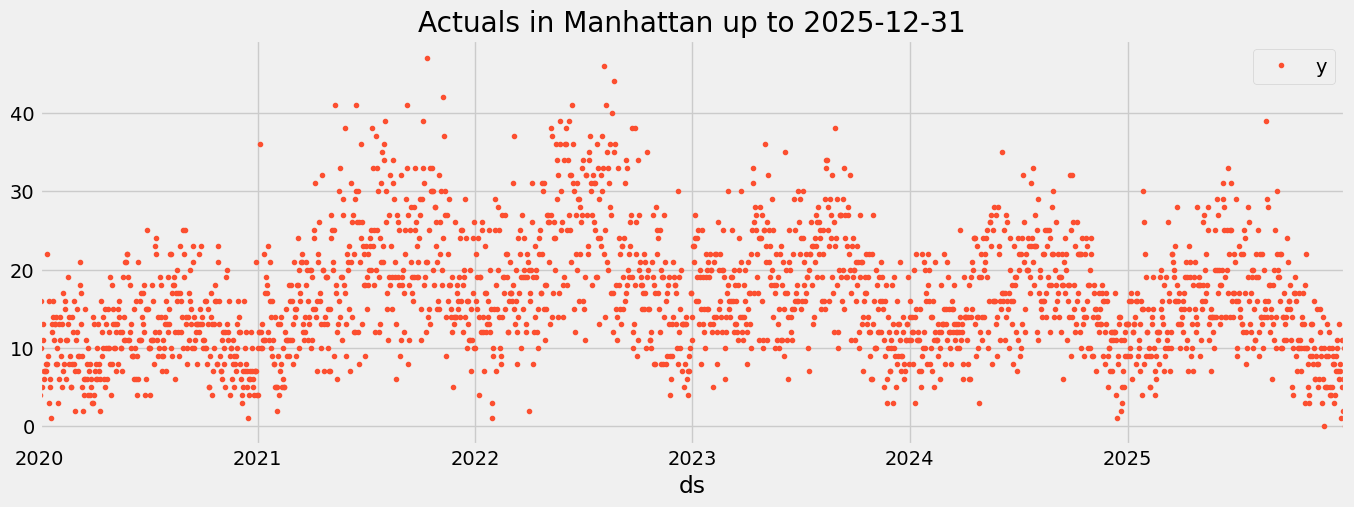

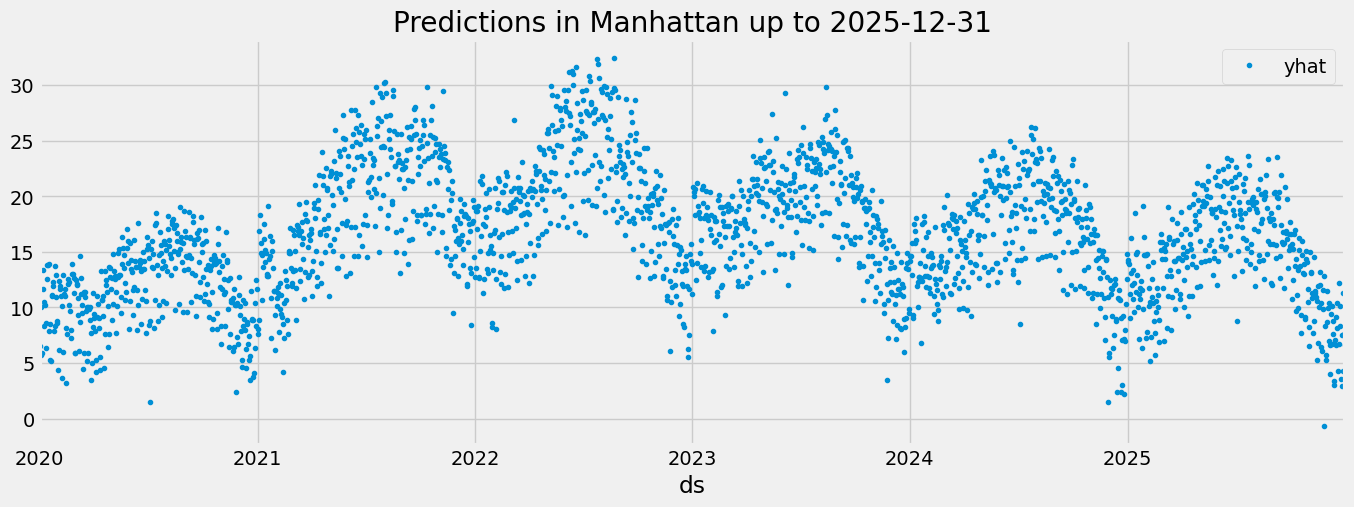

In [386]:
# fix index before plotting

xgbpp= xgbpp.set_index('ds')
xgbpp.index = pd.to_datetime(xgbpp.index)
df= df.set_index('ds')
df.index = pd.to_datetime(df.index)

# plot
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[1],
        title='Actuals in Manhattan up to 2025-12-31')
plt.show()

xgbpp.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='Predictions in Manhattan up to 2025-12-31')

plt.show()

In [387]:
print(f"The RMSE of our predictions against the data frmo 2020-01-1 to 2025-12-31 is:\n{np.sqrt(mean_squared_error(df['y'], xgbpp['yhat']))}")


The RMSE of our predictions against the data frmo 2020-01-1 to 2025-12-31 is:
4.285976423717757


# How does an XGBoosted Prophet model fare against the data for 2026?

The dates for 2026 that we will use are for the dates from 2026-01-01 to 2026-02-28 inclusive. There are 59 days from 2026-01-01 to 2026-02-28 inclusove so we set periods to 59.

In [388]:
future_dates = m.make_future_dataframe(periods=59)
future_pp = m.predict(future_dates)[['ds','yhat']]

In [389]:
# add new dates to df

new_dates = pd.date_range(start="2026-01-01", end="2026-02-28", freq="D")
new_df = pd.DataFrame({'y': [0] * len(new_dates)}, index=new_dates)

df = pd.concat([df, new_df])
df.index.name = 'ds'


In [390]:
# prepare the inputs to predict residuals for the future
future_residuals = df.copy()
future_residuals.drop(columns=['y'], inplace=True)
future_residuals['y'] = residuals[TARGET]

In [391]:
# Add weather data but all the way upt to 2026-02-28

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdatafuture.csv")
    nd = nd.set_index('date')
    fwd = nd

else:
    fwd = pd.DataFrame(data["daily"])
    fwd["date"] = pd.to_datetime(fwd["time"])
    fwd = fwd.set_index("date")

In [392]:
# add all the futures we can use to the list

future_residuals = create_features(future_residuals)
future_residuals = add_lags(future_residuals)
future_residuals = add_cyclic(future_residuals)
future_residuals = add_lags(future_residuals)
future_residuals = add_seasonal_lags(future_residuals)
future_residuals = add_moving_averages(future_residuals)
future_residuals = add_weather_data(future_residuals,fwd)
future_residuals = add_more_weather_feature(future_residuals)
future_residuals = add_federal_holidays(future_residuals, custom_holidays = ['12-31'])
future_residuals = add_law_flag(future_residuals, law_name='Trash_Law', start_date = '2024-03-01')
future_residuals = add_law_flag(future_residuals, law_name = 'New_Trash_Law', start_date = '2024-11-01')
future_residuals = add_law_flag(future_residuals, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
future_residuals = add_law_flag(future_residuals, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

In [393]:
# one last check of what future_residuals looks like
future_residuals

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,...,apparent_temperature_min_lag300,apparent_temperature_min_lag330,apparent_temperature_min_lag360,apparent_temperature_min_lag365,apparent_temperature_min_lag730,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,-1.567836,2,1,1,2020,1,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,-0.430404,3,1,1,2020,2,2,1,-1.567836,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,9.154759,4,1,1,2020,3,3,1,-0.430404,-1.567836,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,7.441904,5,1,1,2020,4,4,1,9.154759,-0.430404,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,0.532854,6,1,1,2020,5,5,1,7.441904,9.154759,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,NaN,1,1,2,2026,55,24,9,NaN,NaN,...,12.1,7.0,-9.1,-4.6,-11.1,0,1,1,1,1
2026-02-25,NaN,2,1,2,2026,56,25,9,NaN,NaN,...,7.1,-0.6,-13.5,0.1,-6.9,0,1,1,1,1
2026-02-26,NaN,3,1,2,2026,57,26,9,NaN,NaN,...,12.9,-4.2,-10.2,-1.4,-4.1,0,1,1,1,1


In [394]:
# use our model to predict future residuals

future_xgbp = reg.predict(future_residuals[FEATURES])

In [395]:
# set dates for later use
dates = m.make_future_dataframe(periods=59)


In [396]:
# clean up the dataframe of our predictions for residuals
future_dates['yhat'] = future_xgbp
future_xgbp = future_dates
future_dates = future_dates.drop(columns=['yhat'])
future_xgbp


,ds,yhat
0,2020-01-01,1.005973
1,2020-01-02,2.743063
2,2020-01-03,3.184031
3,2020-01-04,3.184031
4,2020-01-05,1.460773
...,...,...
2246,2026-02-24,-2.016240
2247,2026-02-25,-1.882602
2248,2026-02-26,-1.030273
2249,2026-02-27,-1.575174


In [397]:
# combine our results
future_xgbpp = future_pp.copy()
future_xgbpp['yhat'] += future_xgbp['yhat']
future_xgbpp= future_xgbpp.set_index('ds')
future_xgbpp.index = pd.to_datetime(future_xgbpp.index)

In [398]:
# Prepare the data so we can obtain the actuals for 2026-01-01 to 2026-02-28

df26 = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs26.csv')
df26['created_date'] = pd.to_datetime(df26['created_date']) 
df26 = df26[df26['borough']=='MANHATTAN']
full_dates = pd.date_range('2026-01-01', '2026-02-28', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df26 = df26.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df26['count'] = df26['count'].astype(int)
df26.drop(columns=['borough'], inplace=True)
df26 = df26.rename(columns = {'created_date' : 'ds', 'count':'y'})
df26= df26.set_index('ds')
df26.index = pd.to_datetime(df26.index)

# Add the 2026 data to df for plotting and comparison
df_future = df.copy()
df_future.loc[df26.index, 'y'] = df26['y']

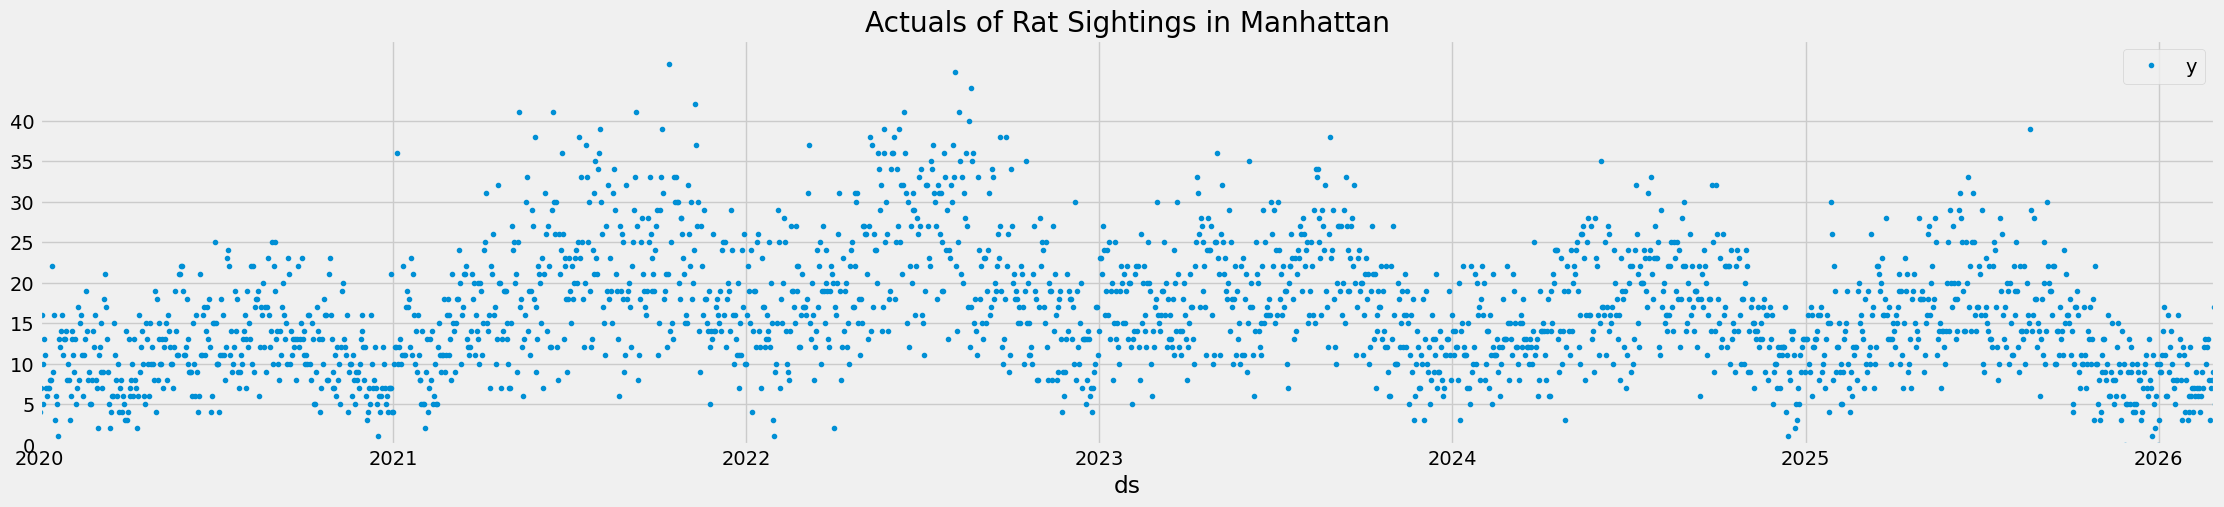

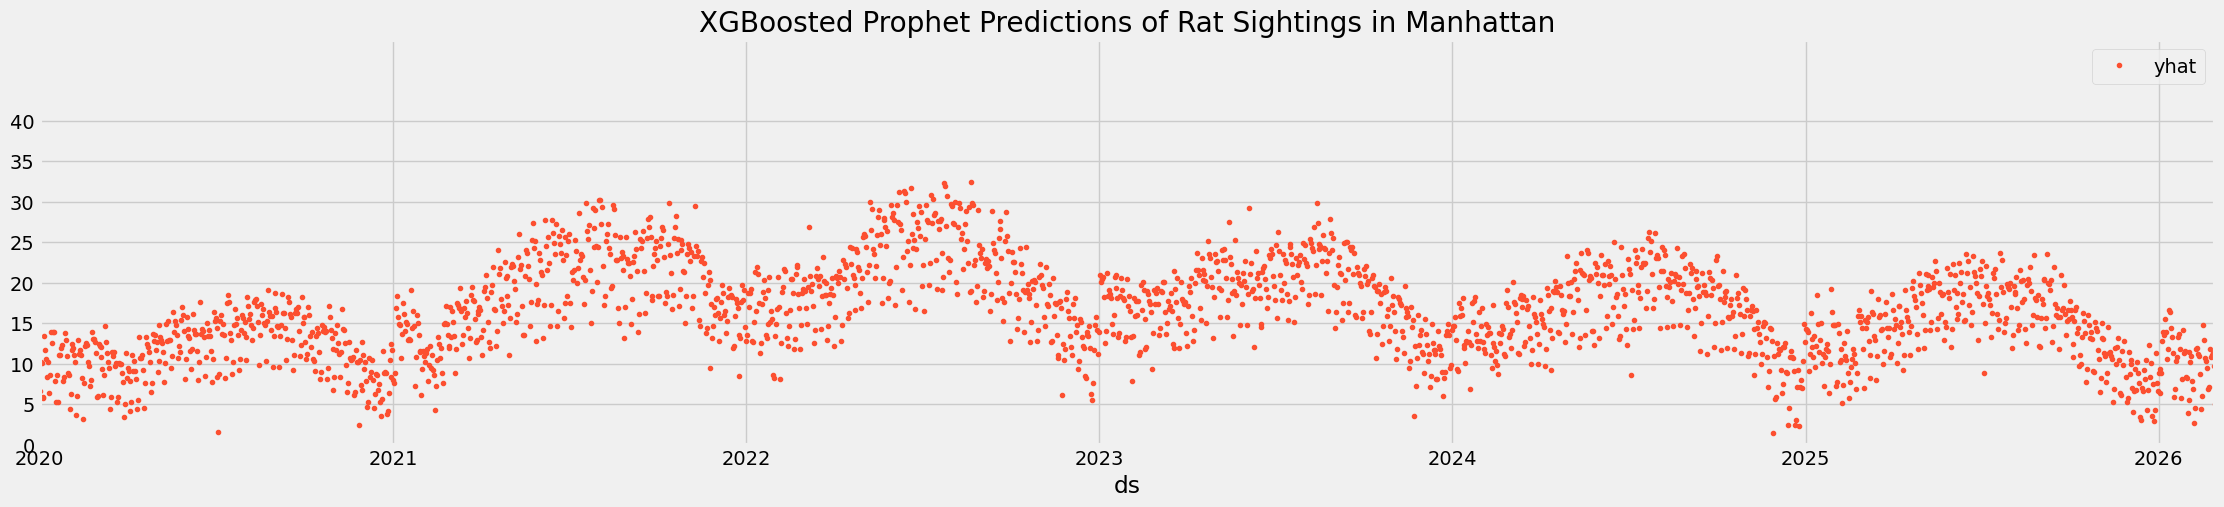

In [399]:
ax1 = df_future.plot(style='.',
                     figsize=(25, 5),
                     color=color_pal[0],
                     title='Actuals of Rat Sightings in Manhattan')

ax1.set_ylim(0, 50)
ax1.set_yticks(np.arange(0, 41, 5))  # ticks every 5 units
plt.show()

ax2 = future_xgbpp.plot(style='.',
                        figsize=(25, 5),
                        color=color_pal[1],
                        title='XGBoosted Prophet Predictions of Rat Sightings in Manhattan')

ax2.set_ylim(0, 50)
ax2.set_yticks(np.arange(0, 41, 5))
plt.show()

In [400]:
print(f"The RMSE of our predictions against the data from 2020-01-1 to 2026-02-328 is: {np.sqrt(mean_squared_error(df_future['y'], future_xgbpp['yhat'])).round(2)}")

The RMSE of our predictions against the data from 2020-01-1 to 2026-02-328 is: 4.28


In [401]:
# Filter df_future and future_xgbpp to the dates from 2026-01-01 to 2026-02-28 (index is the date)
df_future_filtered = df_future.loc[(df_future.index >= '2026-01-01') & (df_future.index <= '2026-02-28')]
future_xgbpp_filtered = future_xgbpp.loc[(future_xgbpp.index >= '2026-01-01') & (future_xgbpp.index <= '2026-02-28')]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(df_future_filtered['y'], future_xgbpp_filtered['yhat']))

print(f"The RMSE of our predictions against the data from 2026-01-01 to 2026-02-28 is: {rmse.round(4)}")

# Filter df_future and future_xgbpp to the dates from 2026-01-01 to 2026-02-28 (index is the date)
future_pp_filtered = future_pp.loc[(future_pp['ds'] >= '2026-01-01') & (future_pp['ds'] <= '2026-02-28')]

# Calculate RMSE
rmsep = np.sqrt(mean_squared_error(df_future_filtered['y'], future_pp_filtered['yhat']))

print(f"The RMSE of Prophet against the data from 2026-01-01 to 2026-02-28 is: {rmsep.round(4)}")

print(f"XGBoosting lead to an RMSE reuduction of change of {((rmse-rmsep)).round(4)}.\nIf this is >0, then we did worse.\nIf this is <0, then we did better.")

The RMSE of our predictions against the data from 2026-01-01 to 2026-02-28 is: 3.8498
The RMSE of Prophet against the data from 2026-01-01 to 2026-02-28 is: 4.1737
XGBoosting lead to an RMSE reuduction of change of -0.3239.
If this is >0, then we did worse.
If this is <0, then we did better.


## Conclusion on improvements

The improvement on RMSE for the data from 2026-01-01 to 2026-02-28 is minimal (roughly 0.2) each time. Whether or not it is worth the effort to do this is probably up to the user. If one looks at the graph using both models as oposed to just using prophet, it looks like it captures the random jumps in rat sightings more accurately.

WARNING: The data for weather I am storing has a limit on number of requests. We should probably save that data beforehand. Make sure to check that the future weather data is genuinely being used! You can see this by checking the future_residuals dataframe and observing whether or not the weather data is there! The last 5 days are displayed below!

03-04-2026: After a few more runes, this only ever seems to improve by around 0.2-0.3. The improvements on the model does not indicate to me that this is worth using.

In [402]:
future_residuals.tail(5)

,y,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,...,apparent_temperature_min_lag300,apparent_temperature_min_lag330,apparent_temperature_min_lag360,apparent_temperature_min_lag365,apparent_temperature_min_lag730,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2026-02-24,NaN,1,1,2,2026,55,24,9,NaN,NaN,...,12.1,7.0,-9.1,-4.6,-11.1,0,1,1,1,1
2026-02-25,NaN,2,1,2,2026,56,25,9,NaN,NaN,...,7.1,-0.6,-13.5,0.1,-6.9,0,1,1,1,1
2026-02-26,NaN,3,1,2,2026,57,26,9,NaN,NaN,...,12.9,-4.2,-10.2,-1.4,-4.1,0,1,1,1,1
2026-02-27,NaN,4,1,2,2026,58,27,9,NaN,NaN,...,18.2,4.1,-6.1,1.0,0.0,0,1,1,1,1
2026-02-28,NaN,5,1,2,2026,59,28,9,NaN,NaN,...,15.5,10.2,2.7,-2.0,-9.0,0,1,1,1,1


## Which features were important?

We analyze which features were important for XGBoost predictions of the residuals.

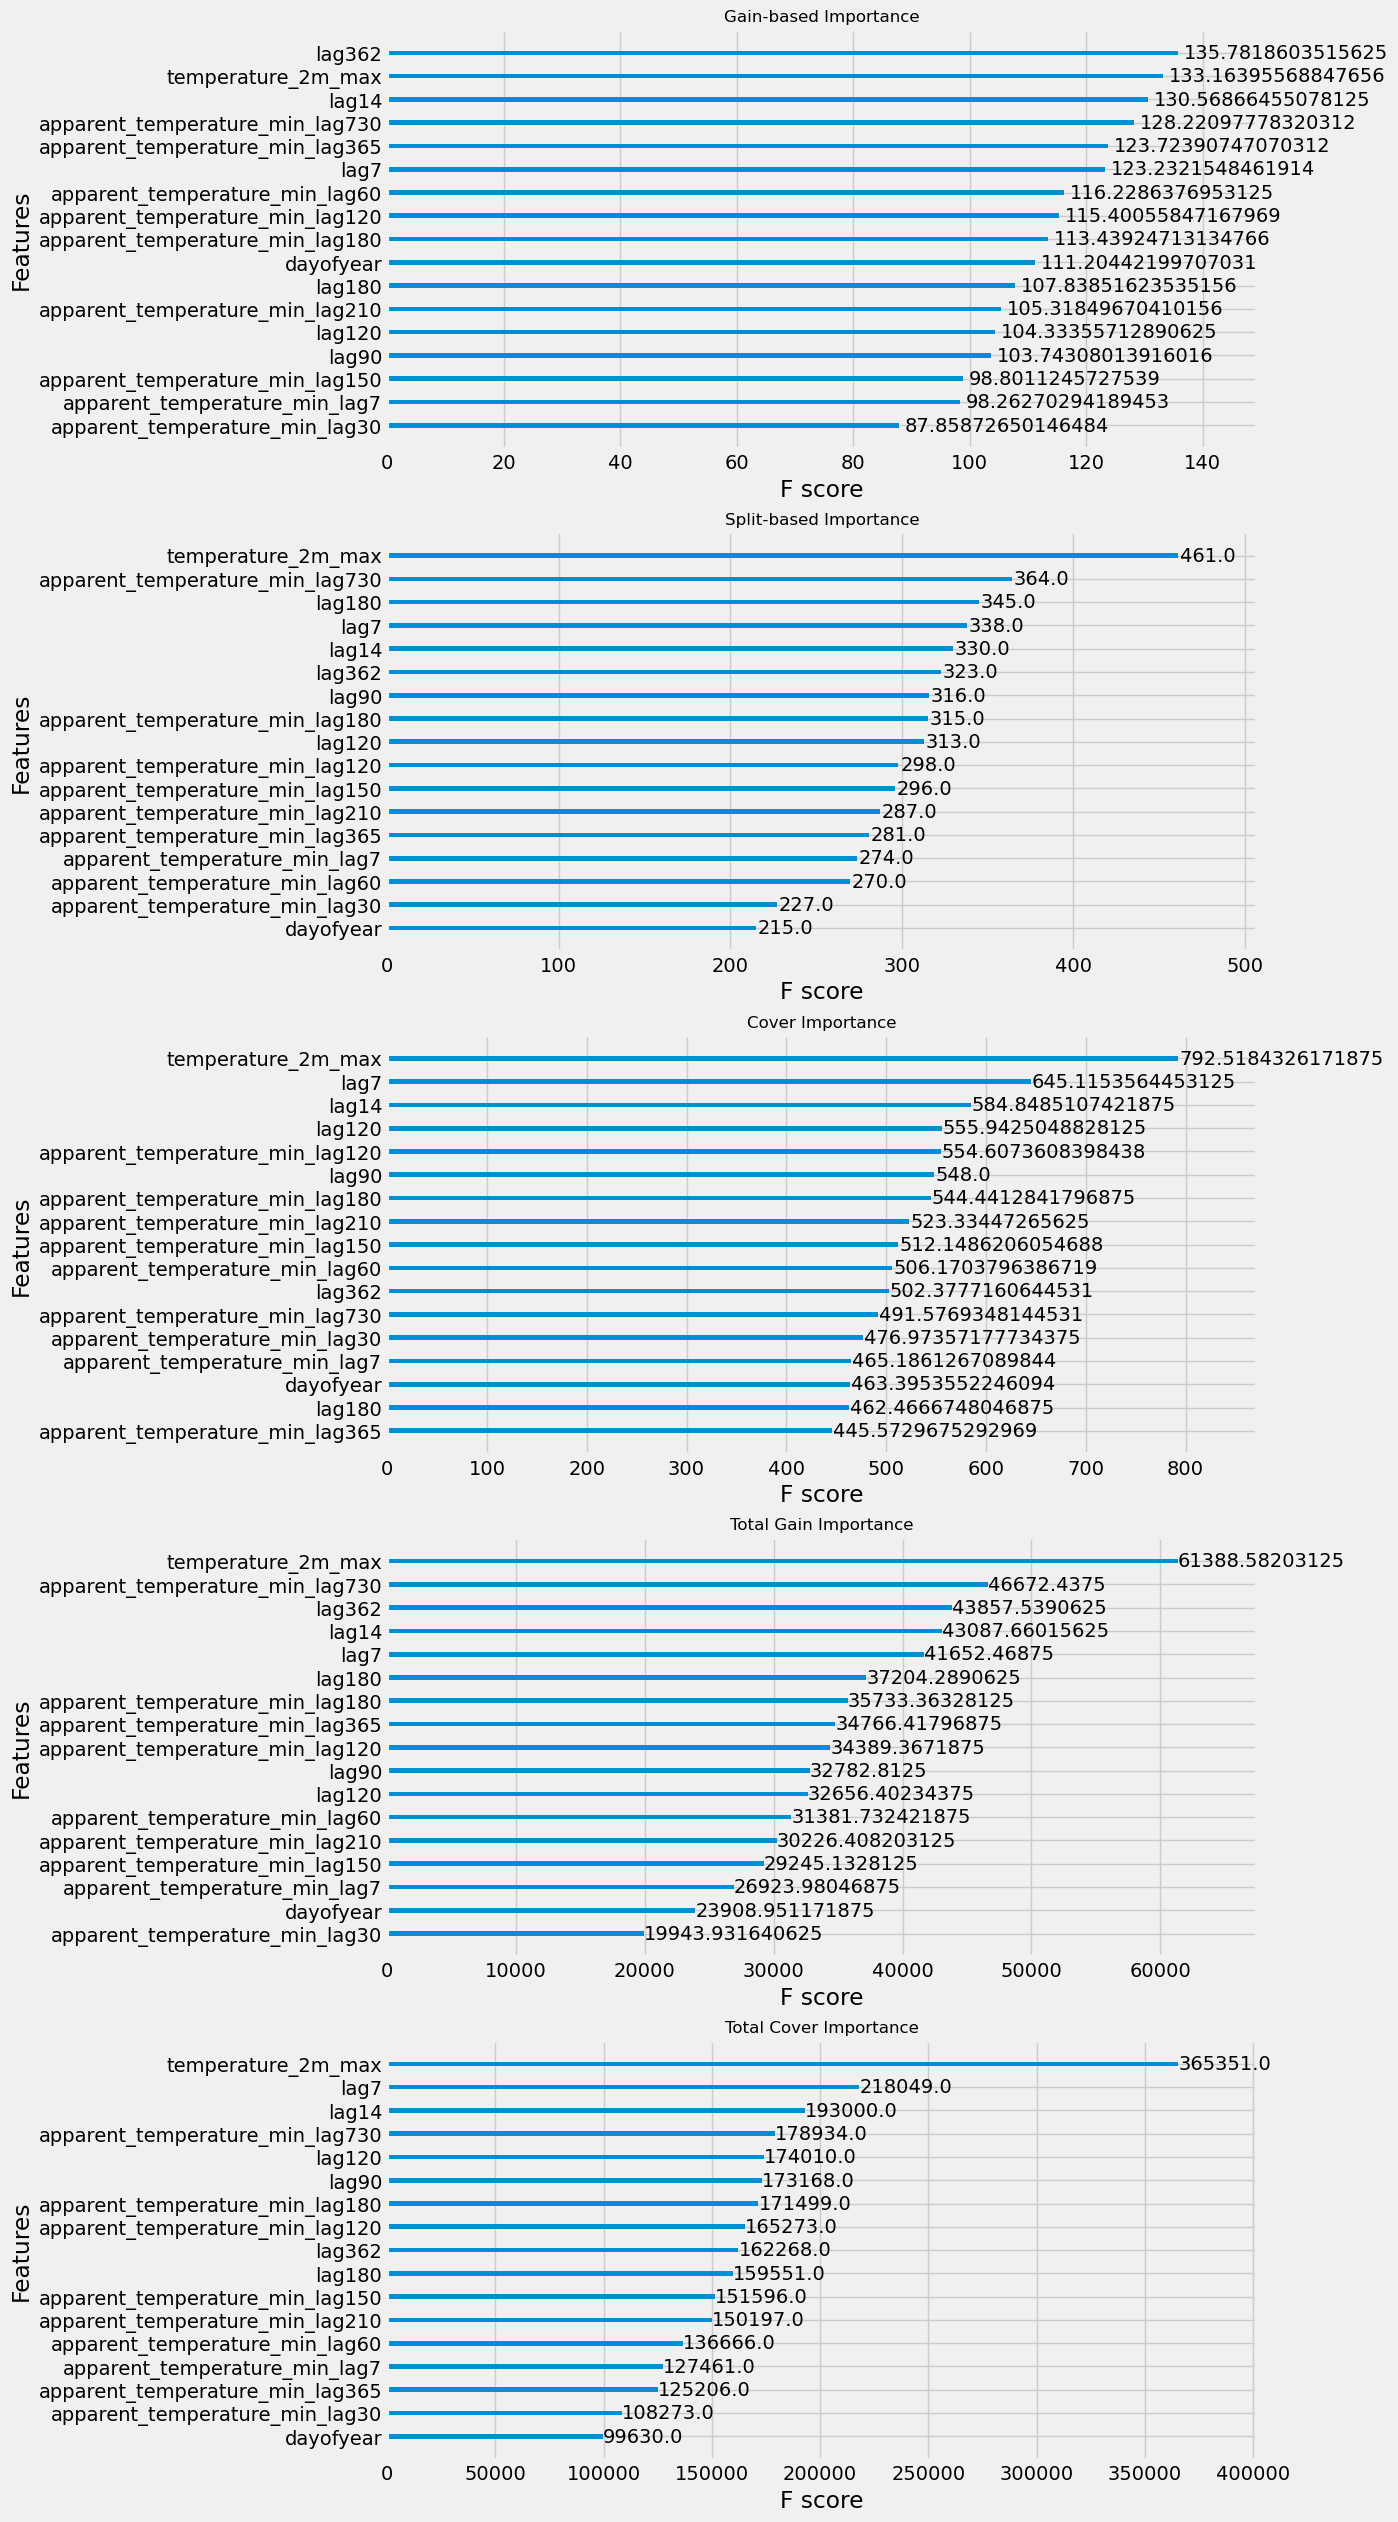

In [403]:
from xgboost import plot_importance

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))

plot_importance(reg, ax=ax1, importance_type='gain')
ax1.set_title('Gain-based Importance', fontsize=12)

plot_importance(reg, ax=ax2, importance_type='weight')
ax2.set_title('Split-based Importance', fontsize=12)

plot_importance(reg, ax=ax3, importance_type='cover')
ax3.set_title('Cover Importance', fontsize=12)

plot_importance(reg, ax=ax4, importance_type='total_gain')
ax4.set_title('Total Gain Importance', fontsize=12)

plot_importance(reg, ax=ax5, importance_type='total_cover')
ax5.set_title('Total Cover Importance', fontsize=12)

plt.show()